In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
save_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/tables")
save_dir.mkdir(parents=True, exist_ok=True)

In [5]:
def collect_wandb_run_dirs(
        sweep_dir,
        type_of_run: Literal['run', 'offline-run']='run'
    ):
    wandb_run_dirs = []
    for d in os.listdir(sweep_dir / "wandb"):
        if type_of_run in d:
            # print(d)
            wandb_run_dirs.append(sweep_dir / "wandb" / d)
    return wandb_run_dirs

In [6]:
def build_sweep_test_results_df(
        wandb_run_dirs,
        split: Literal['1-test-patch', '3-test-patch']='1-test-patch',
        conditioning=True
    ):
    wandb_run_dir_dfs = []
    for wandb_run_dir in wandb_run_dirs:
        if isinstance(wandb_run_dir, str):
            cfg = f"{wandb_run_dir}/files/user_specified_config.yaml"
            test_res_file = f"{wandb_run_dir}/files/results/test_metrics.csv"
        else:
            cfg = wandb_run_dir/"files"/"user_specified_config.yaml"
            test_res_file = wandb_run_dir/"files"/"results"/"test_metrics.csv"
        with open(cfg, 'r') as f:
            cfg = yaml.safe_load(f)
        test_results_df = pd.read_csv(test_res_file)
        
        test_results_df['dataset'] = cfg['dataset']['dataset_name']
        test_results_df['seed'] = cfg['experiment']['seed']
        if conditioning:
            test_results_df['model'] = cfg['model']['model_name']
        else:
            test_results_df['model'] = f"{cfg['model']['model_name']} w/o C"
        test_results_df['split'] = split

        wandb_run_dir_dfs.append(test_results_df)
        
    sweep_results = pd.concat(
        objs=wandb_run_dir_dfs,
        ignore_index=True
    )

    return sweep_results

In [7]:
def build_clean_sweep_results_df(
        df: pd.DataFrame,
        metrics: List[str] = [
            "pearson_1hop_nbr",
            "pearson_gene_wise_1hop_nbr",
            "mmd_1hop_nbr",
            "mmd_pca_1hop_nbr",
        ]
    ):
    # --- Step 1: groupby and transpose ---
    df_long = df.melt(
        id_vars=["dataset", "seed", "model", "split"], 
        var_name="metric", 
        value_name="value"
    )
    
    # --- Step 2: strip mode from metric name ---
    df_long["mode"] = df_long["metric"].str.extract(r"^(train|val|test)")
    df_long["metric"] = df_long["metric"].str.replace(r"^(train|val|test)_", "", regex=True)
    df_long = df_long[df_long['metric'].isin(metrics)]

    # --- Step 3: pretty names for metric ---
    metric_rename = {
        "pearson_1hop_nbr": "PC",
        "mmd_1hop_nbr": "MMD",
        "energy_pca_1hop_nbr": "E",
        "energy_1hop_nbr": "E1",
    }
    df_long["metric"] = df_long["metric"].map(metric_rename)

    # --- Step 4: pretty names for model ---
    model_rename = {
        "VQNiche": "SQUINT",
        "VQNiche w/o C": "SQUINT w/o C",
        "WFM": "WFM",
    }
    df_long["model"] = df_long["model"].map(model_rename)
    
    # --- Step 5: pretty names for dataset ---
    dataset_rename = {
        "xhs1000-39b_1p": "Skin (Human)",
        "mmb0-4b_1p": "Brain (Mouse)",
        "xhk1020-CV1-CV2-5b_1p": "Kidney (Human)",
    }
    df_long["dataset"] = df_long["dataset"].map(dataset_rename)
    
    # --- Step 6: pretty names for split ---
    split_rename = {
        "1-test-patch": "1 Patch",
        "3-test-patch": "3 Patches",
    }
    df_long["split"] = df_long["split"].map(split_rename)
    
    # --- Step 7: round to 4 decimals ---
    df_long['value'] = df_long['value'].round(4)
    
    df_long = df_long.drop_duplicates()
    
    return df_long

In [43]:
df_datasets = []
metrics = [
    "pearson_1hop_nbr",
    # "pearson_cell_wise",
    # "pearson_gene_wise_1hop_nbr",
    "mmd_1hop_nbr",
    # "mmd_pca_1hop_nbr",
    # "energy_pca_1hop_nbr",
    "energy_1hop_nbr",
]

# Dataset: mmb04-4b_1p

### Conditioning with RBF Distances + Batch-ID: 0 MLP Layers

In [44]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20251125-093846")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 0
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1100,0.481075,0.725655,0.086759,0.259110,0.138561,0.002460,4,mmb0-4b_1p,0,VQNiche,3-test-patch
1,0.0926,0.533089,0.766345,0.087853,0.249523,0.141685,0.002465,4,mmb0-4b_1p,2,VQNiche,3-test-patch
2,0.0684,0.543894,0.786945,0.100685,0.270944,0.129288,0.002464,4,mmb0-4b_1p,1,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Brain (Mouse),0,SQUINT,3 Patches,PC,0.7257,test,0
9,Brain (Mouse),2,SQUINT,3 Patches,PC,0.7663,test,0
10,Brain (Mouse),1,SQUINT,3 Patches,PC,0.7869,test,0
20,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.1386,test,0
21,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.1417,test,0
22,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.1293,test,0


### Conditioning with RBF Distances + Batch-ID: 1 MLP Layers

In [45]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20251125-095942")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 1
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.0924,0.508680,0.755353,0.098274,0.267347,0.120710,0.002465,4,mmb0-4b_1p,0,VQNiche,3-test-patch
1,0.1038,0.605393,0.847241,0.115685,0.294933,0.070617,0.002463,4,mmb0-4b_1p,1,VQNiche,3-test-patch
2,0.0798,0.609042,0.844262,0.110154,0.279311,0.089236,0.002466,4,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Brain (Mouse),0,SQUINT,3 Patches,PC,0.7554,test,1
9,Brain (Mouse),1,SQUINT,3 Patches,PC,0.8472,test,1
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.8443,test,1
20,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.1207,test,1
21,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.0706,test,1
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.0892,test,1


### Conditioning with RBF Distances + Batch-ID: 2 MLP Layers

In [46]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20250918-120525")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 2
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0976,0.665215,0.906643,0.127004,0.309582,0.037895,0.00246,0.006198,19.380365,mmb0-4b_1p,0,VQNiche,3-test-patch
1,0.1256,0.664743,0.920757,0.126219,0.293255,0.039721,0.00246,0.004190,17.040207,mmb0-4b_1p,1,VQNiche,3-test-patch
2,0.1098,0.665079,0.920793,0.126838,0.298615,0.040766,0.00246,0.004737,18.873299,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9066,test,2
9,Brain (Mouse),1,SQUINT,3 Patches,PC,0.9208,test,2
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.9208,test,2
20,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0379,test,2
21,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.0397,test,2
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.0408,test,2
28,Brain (Mouse),0,SQUINT,3 Patches,E1,0.0062,test,2
29,Brain (Mouse),1,SQUINT,3 Patches,E1,0.0042,test,2
30,Brain (Mouse),2,SQUINT,3 Patches,E1,0.0047,test,2


# Dataset: xhk1020-CV1-CV2-5b_1p

### Conditioning with RBF Distances + Batch-ID: 0 MLP Layers

In [47]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20251130-140507")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 0
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.0286,0.525772,0.873934,0.053999,0.351375,0.027658,0.000879,1,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch
1,0.0222,0.480893,0.863851,0.048645,0.352741,0.022636,0.000850,1,xhk1020-CV1-CV2-5b_1p,1,VQNiche,3-test-patch
2,0.0286,0.525772,0.873934,0.053999,0.351375,0.027658,0.000879,1,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Kidney (Human),2,SQUINT,3 Patches,PC,0.8739,test,0
9,Kidney (Human),1,SQUINT,3 Patches,PC,0.8639,test,0
11,Kidney (Human),0,SQUINT,3 Patches,PC,0.8605,test,0
20,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0277,test,0
21,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0226,test,0
23,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0292,test,0


### Conditioning with RBF Distances + Batch-ID: 1 MLP Layers

In [48]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20251130-160539")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 1
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.0314,0.502489,0.866184,0.054987,0.356555,0.022021,0.000857,1,xhk1020-CV1-CV2-5b_1p,0,VQNiche,3-test-patch
1,0.0264,0.531157,0.879999,0.051344,0.357025,0.027346,0.000862,1,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch
2,0.0214,0.477222,0.858878,0.053081,0.354543,0.025036,0.000862,1,xhk1020-CV1-CV2-5b_1p,1,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Kidney (Human),0,SQUINT,3 Patches,PC,0.8662,test,1
9,Kidney (Human),2,SQUINT,3 Patches,PC,0.8800,test,1
10,Kidney (Human),1,SQUINT,3 Patches,PC,0.8589,test,1
20,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0220,test,1
21,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0273,test,1
22,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0250,test,1


### Conditioning with RBF Distances + Batch-ID: 2 MLP Layers

In [49]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20250918-133207")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 2
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.024,0.508650,0.870048,0.058456,0.365251,0.018435,0.000848,0.002834,1.147923,xhk1020-CV1-CV2-5b_1p,0,VQNiche,3-test-patch
1,0.024,0.501943,0.867359,0.050387,0.366539,0.021097,0.000855,0.003627,1.193336,xhk1020-CV1-CV2-5b_1p,1,VQNiche,3-test-patch
2,0.025,0.497489,0.868739,0.054344,0.371600,0.018810,0.000851,0.002724,1.058001,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Kidney (Human),0,SQUINT,3 Patches,PC,0.8700,test,2
9,Kidney (Human),1,SQUINT,3 Patches,PC,0.8674,test,2
10,Kidney (Human),2,SQUINT,3 Patches,PC,0.8687,test,2
20,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0184,test,2
21,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0211,test,2
22,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0188,test,2
28,Kidney (Human),0,SQUINT,3 Patches,E1,0.0028,test,2
29,Kidney (Human),1,SQUINT,3 Patches,E1,0.0036,test,2
30,Kidney (Human),2,SQUINT,3 Patches,E1,0.0027,test,2


# Dataset: xhs1000-39b_1p-oriented-7

### Conditioning with RBF Distances + Batch-ID: 0 MLP Layers

In [50]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20251130-151623")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 0
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1188,0.389137,0.703801,0.114579,0.288153,0.127428,0.003635,0.021487,2.707390,4,xhs1000-39b_1p,0,VQNiche,3-test-patch
1,0.1038,0.360492,0.652131,0.098014,0.268728,0.163935,0.003707,0.027503,1.604900,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
2,0.0994,0.369112,0.665602,0.102004,0.273527,0.142051,0.003737,0.023869,1.964638,4,xhs1000-39b_1p,1,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Skin (Human),0,SQUINT,3 Patches,PC,0.7038,test,0
9,Skin (Human),2,SQUINT,3 Patches,PC,0.6521,test,0
10,Skin (Human),1,SQUINT,3 Patches,PC,0.6656,test,0
20,Skin (Human),0,SQUINT,3 Patches,MMD,0.1274,test,0
21,Skin (Human),2,SQUINT,3 Patches,MMD,0.1639,test,0
22,Skin (Human),1,SQUINT,3 Patches,MMD,0.1421,test,0
28,Skin (Human),0,SQUINT,3 Patches,E1,0.0215,test,0
29,Skin (Human),2,SQUINT,3 Patches,E1,0.0275,test,0
30,Skin (Human),1,SQUINT,3 Patches,E1,0.0239,test,0


### Conditioning with RBF Distances + Batch-ID: 1 MLP Layers

In [51]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20251130-160418")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 1
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1408,0.380695,0.647511,0.112223,0.302974,0.124994,0.003610,0.022722,5.562344,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
1,0.1698,0.389230,0.691005,0.116943,0.293425,0.133109,0.003625,0.020753,2.895994,4,xhs1000-39b_1p,1,VQNiche,3-test-patch
2,0.1866,0.368405,0.683194,0.116053,0.297507,0.145692,0.003689,0.025041,2.823465,4,xhs1000-39b_1p,0,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Skin (Human),2,SQUINT,3 Patches,PC,0.6475,test,1
9,Skin (Human),1,SQUINT,3 Patches,PC,0.6910,test,1
10,Skin (Human),0,SQUINT,3 Patches,PC,0.6832,test,1
20,Skin (Human),2,SQUINT,3 Patches,MMD,0.1250,test,1
21,Skin (Human),1,SQUINT,3 Patches,MMD,0.1331,test,1
22,Skin (Human),0,SQUINT,3 Patches,MMD,0.1457,test,1
28,Skin (Human),2,SQUINT,3 Patches,E1,0.0227,test,1
29,Skin (Human),1,SQUINT,3 Patches,E1,0.0208,test,1
30,Skin (Human),0,SQUINT,3 Patches,E1,0.0250,test,1


### Conditioning with RBF Distances + Batch-ID: 2 MLP Layers

In [52]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250923-220522")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['MLP Layers'] = 2
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
1,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
2,0.1198,0.437777,0.780558,0.130274,0.309842,0.091400,0.003610,0.012535,6.505773,4,xhs1000-39b_1p,0,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,MLP Layers
8,Skin (Human),2,SQUINT,3 Patches,PC,0.7847,test,2
10,Skin (Human),0,SQUINT,3 Patches,PC,0.7806,test,2
11,Skin (Human),1,SQUINT,3 Patches,PC,0.7994,test,2
20,Skin (Human),2,SQUINT,3 Patches,MMD,0.0987,test,2
22,Skin (Human),0,SQUINT,3 Patches,MMD,0.0914,test,2
23,Skin (Human),1,SQUINT,3 Patches,MMD,0.0881,test,2
28,Skin (Human),2,SQUINT,3 Patches,E1,0.0145,test,2
30,Skin (Human),0,SQUINT,3 Patches,E1,0.0125,test,2
31,Skin (Human),1,SQUINT,3 Patches,E1,0.0118,test,2


# Results Dataframe

In [53]:
df_full = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
display(df_full.head(3))

,dataset,seed,model,split,metric,value,mode,MLP Layers
0,Brain (Mouse),0,SQUINT,3 Patches,PC,0.7257,test,0
1,Brain (Mouse),2,SQUINT,3 Patches,PC,0.7663,test,0
2,Brain (Mouse),1,SQUINT,3 Patches,PC,0.7869,test,0


In [54]:
df_avg = df_full.groupby(
        ['dataset', 'split', 'model', 'metric', 'MLP Layers']
        )['value'].mean().reset_index()
df_avg = df_avg.round(4)
display(df_avg)

,dataset,split,model,metric,MLP Layers,value
0,Brain (Mouse),3 Patches,SQUINT,E1,2,0.0050
1,Brain (Mouse),3 Patches,SQUINT,MMD,0,0.1365
2,Brain (Mouse),3 Patches,SQUINT,MMD,1,0.0935
3,Brain (Mouse),3 Patches,SQUINT,MMD,2,0.0395
4,Brain (Mouse),3 Patches,SQUINT,PC,0,0.7596
5,Brain (Mouse),3 Patches,SQUINT,PC,1,0.8156
6,Brain (Mouse),3 Patches,SQUINT,PC,2,0.9161
7,Kidney (Human),3 Patches,SQUINT,E1,2,0.0030
8,Kidney (Human),3 Patches,SQUINT,MMD,0,0.0265
9,Kidney (Human),3 Patches,SQUINT,MMD,1,0.0248


# Plot

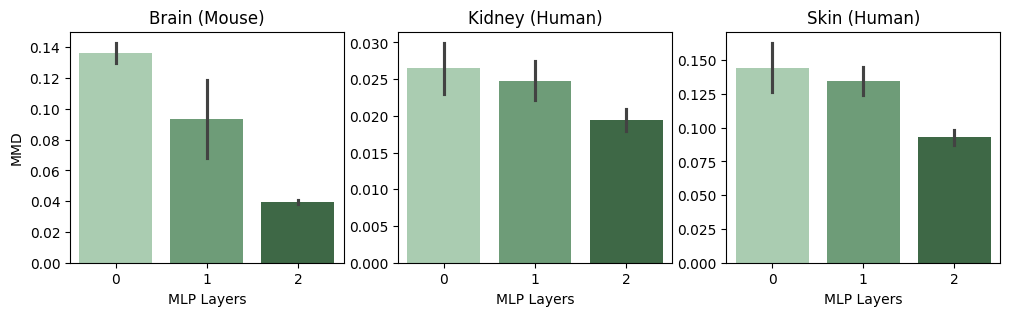

In [57]:
df_metric = df_full[df_full['metric'] == 'MMD']
datasets = df_metric['dataset'].unique().tolist()

palette = sns.cubehelix_palette(start=2, rot=0, dark=0.35, light=0.75, as_cmap=True)

# Create the plot
fig, axes = plt.subplots(1,3,figsize=(12,3))

for i, ax in enumerate(axes):
    df_dataset = df_metric[df_metric['dataset'] == datasets[i]]
    
    sns.barplot(
        data=df_dataset,
        x='MLP Layers',
        y='value',
        hue='MLP Layers',
        palette=palette,
        errorbar="sd",
        legend=False,
        ax=ax
    )

    # Customize the plot
    if i == 0:
        ax.set_ylabel('MMD')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('MLP Layers')
    ax.set_title(datasets[i])

# Show the plot
plt.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/ablations/mlp_layers.pdf", bbox_inches='tight')
# plt.show()

# Results Table

In [65]:
df_metric = df_full[df_full['metric'] == 'MMD']
grouped = df_metric.groupby(['dataset', 'MLP Layers', 'split', 'model', 'metric'])['value'].agg(['mean', 'std']).reset_index()

# Combine mean and std dev into a single string
grouped['value'] = grouped.apply(lambda row: f"{row['mean']:.4f} $\\pm$ {row['std']:.4f}", axis=1)

display(grouped)

,dataset,MLP Layers,split,model,metric,mean,std,value
0,Brain (Mouse),0,3 Patches,SQUINT,MMD,0.136533,0.006453,0.1365 $\pm$ 0.0065
1,Brain (Mouse),1,3 Patches,SQUINT,MMD,0.093500,0.025325,0.0935 $\pm$ 0.0253
2,Brain (Mouse),2,3 Patches,SQUINT,MMD,0.039467,0.001464,0.0395 $\pm$ 0.0015
3,Kidney (Human),0,3 Patches,SQUINT,MMD,0.026500,0.003460,0.0265 $\pm$ 0.0035
4,Kidney (Human),1,3 Patches,SQUINT,MMD,0.024767,0.002658,0.0248 $\pm$ 0.0027
5,Kidney (Human),2,3 Patches,SQUINT,MMD,0.019433,0.001457,0.0194 $\pm$ 0.0015
6,Skin (Human),0,3 Patches,SQUINT,MMD,0.144467,0.018365,0.1445 $\pm$ 0.0184
7,Skin (Human),1,3 Patches,SQUINT,MMD,0.134600,0.010431,0.1346 $\pm$ 0.0104
8,Skin (Human),2,3 Patches,SQUINT,MMD,0.092733,0.005424,0.0927 $\pm$ 0.0054


In [66]:
# create pivot table
pivot = grouped.pivot(
    index='MLP Layers',
    columns='dataset',
    values='value'
)

# display as markdown
print(pivot.to_markdown())

|   MLP Layers | Brain (Mouse)       | Kidney (Human)      | Skin (Human)        |
|-------------:|:--------------------|:--------------------|:--------------------|
|            0 | 0.1365 $\pm$ 0.0065 | 0.0265 $\pm$ 0.0035 | 0.1445 $\pm$ 0.0184 |
|            1 | 0.0935 $\pm$ 0.0253 | 0.0248 $\pm$ 0.0027 | 0.1346 $\pm$ 0.0104 |
|            2 | 0.0395 $\pm$ 0.0015 | 0.0194 $\pm$ 0.0015 | 0.0927 $\pm$ 0.0054 |


In [59]:
# choose one metric & model to display
subset = df_avg[(df_avg['metric'] == 'MMD') & (df_avg['model'] == 'SQUINT')]

# create pivot table
pivot = subset.pivot_table(
    index='MLP Layers',
    columns='dataset',
    values='value'
).round(4)

# display as markdown
print(pivot.to_markdown())

|   MLP Layers |   Brain (Mouse) |   Kidney (Human) |   Skin (Human) |
|-------------:|----------------:|-----------------:|---------------:|
|            0 |          0.1365 |           0.0265 |         0.1445 |
|            1 |          0.0935 |           0.0248 |         0.1346 |
|            2 |          0.0395 |           0.0194 |         0.0927 |
